In [ ]:
# dataset link
# https://www.kaggle.com/datasets/mariospirito/position-salariescsv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [153]:
dataset = pd.read_csv("Position_Salaries.csv")
X = dataset.iloc[:,1:-1].to_numpy()
y = dataset.iloc[:,-1].to_numpy()

dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)


np.set_printoptions(suppress=True, precision=2)
X_test


array([[ 3],
       [10],
       [ 7],
       [ 5]])

In [155]:
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_train_sc = scaler_x.fit_transform(X_train)
X_test_sc = scaler_x.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1))

X_train_sc



array([[-1.36],
       [-0.34],
       [-1.02],
       [ 1.02],
       [ 1.36],
       [ 0.34]])

In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


# 1 multiple LR
linear_reg = LinearRegression()
linear_reg.fit(X_train_sc, y_train_sc)


# 2 Polynomial Regression
poly = PolynomialFeatures()
poly_reg = LinearRegression()
X_poly = poly.fit_transform(X_train_sc)
poly_reg.fit(X_poly, y_train_sc)



# 3️ Support Vector Regression

svr = SVR(kernel="rbf")
svr.fit(X_train_sc, y_train_sc)


# 4️ Decision Tree Regression
dt_reg = DecisionTreeRegressor(random_state=1)
dt_reg.fit(X_train, y_train)


# 5️ Random Forest Regression
rf_reg = RandomForestRegressor(n_estimators=10, random_state=0)
rf_reg.fit(X_train, y_train)



d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


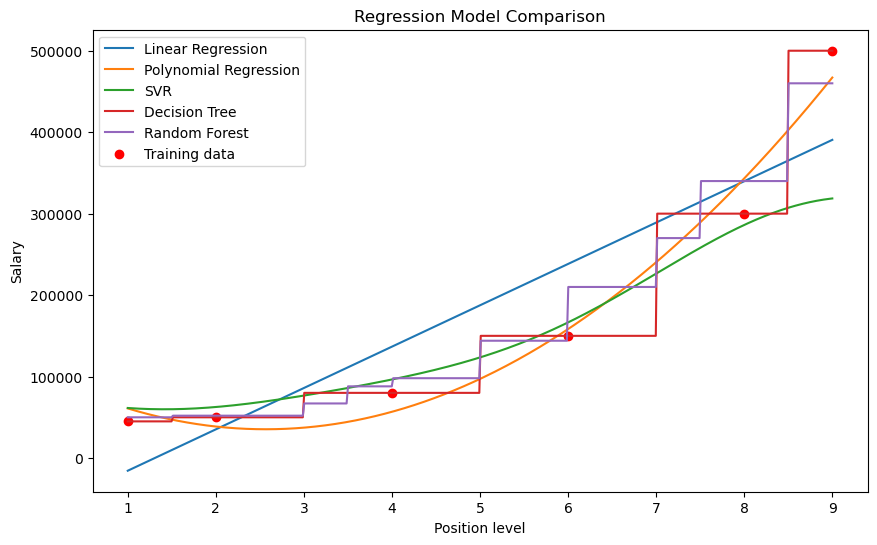

In [ ]:
X_grid = np.linspace(X_train.min(), X_train.max(), 500).reshape(-1, 1)
X_grid_sc = scaler_x.transform(X_grid)


# Linear
plt.plot(X_grid, scaler_y.inverse_transform(linear_reg.predict(X_grid_sc)), label="Linear Regression")

# Polynomial
plt.plot(X_grid, scaler_y.inverse_transform(poly_reg.predict(poly.transform(X_grid_sc))), label="Polynomial Regression")

# SVR
plt.plot(X_grid, scaler_y.inverse_transform(svr.predict(X_grid_sc).reshape(-1,1)), label="SVR")

# Decision Tree
plt.plot(X_grid, dt_reg.predict(X_grid), label="Decision Tree")

# Random Forest
plt.plot(X_grid, rf_reg.predict(X_grid), label="Random Forest")

# Scatter the training points
plt.scatter(X_train, y_train, color="red", label="Training data")
plt.xlabel("Position level")
plt.ylabel("Salary")
plt.title("Regression Model Comparison")
plt.legend()
plt.show()


In [159]:
from sklearn.metrics import mean_squared_error

# Linear
y_pred_lr = scaler_y.inverse_transform(linear_reg.predict(scaler_x.transform(X_test_sc)))
mse_lr = mean_squared_error(y_test, y_pred_lr)

# Polynomial
y_pred_poly = scaler_y.inverse_transform(poly_reg.predict(poly.transform(scaler_x.transform(X_test_sc))))
mse_poly = mean_squared_error(y_test, y_pred_poly)

# SVR
y_pred_svr = scaler_y.inverse_transform(svr.predict(scaler_x.transform(X_test_sc)).reshape(-1,1))
mse_svr = mean_squared_error(y_test, y_pred_svr)

# Decision Tree
y_pred_dt = dt_reg.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)

# Random Forest
y_pred_rf = rf_reg.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)


print(f"Linear Regression: {mse_lr}")
print(f"Polynomial Regression: {mse_poly}")
print(f"SVR: {mse_svr}")
print(f"Decision Tree: {mse_dt}")
print(f"Random Forest: {mse_rf}")


Linear Regression: 267839111534.30624
Polynomial Regression: 234767235046.91928
SVR: 225812763786.9381
Decision Tree: 63375000000.0
Random Forest: 72977000000.0
